# Staleness Analysis: Is the max_hold problem caused by stale z-score entries?

**Hypothesis:** Many `max_hold` exits come from entries where the spread was already
wide at entry — either carried over from a prior session or from multiple prior bars —
rather than freshly diverging. Stale entries have weaker mean-reversion pull and
therefore time out more often.

## Two tests

**Test 1 — Entry-hour proxy (cheap)**  
The first 15-min bar of the day (9:45) is the stalest possible entry: z-score
reflects the overnight carry from the previous close. Later-day entries must have
developed intraday. If staleness drives max_hold, 9:xx entries should show a
materially higher max_hold rate than 10:xx or 11:xx entries.  
Limitation: entry hour is a noisy proxy — a 9:45 entry can be fresh (z just gapped
open) and a 12:00 entry can be stale (z crossed at 11am and we re-enter).  

**Test 3 — z-score at open (direct)**  
For each trade, reconstruct the z-score at the very first bar of the trading day
using the same lookback window as the backtest. If z was already above `z_entry`
at bar 0, the entry is an overnight carry-over (stale). Otherwise it's intraday-fresh.
Compare max_hold rate and P&L between the two groups.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import datetime as dt
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from analysis.preprocessing import load_processed
from utils.config import CONFIG, MINUTES_PER_BAR

# ── Parameters (must match the backtest that produced the parquet) ────────
SNAPSHOT = "../results/snapshots/trades_15min_z35_zh180_zx175_84d_2022-2024.parquet"
TIMEFRAME        = "15min"
Z_ENTRY          = 3.5
ZSCORE_WINDOW_DAYS = 5        # CONFIG.signal.zscore_window_days used in backtest
BARS_PER_DAY     = 26         # 9:30–16:00 in 15-min bars
ZSCORE_WINDOW    = ZSCORE_WINDOW_DAYS * BARS_PER_DAY   # rolling window in bars

trades_df = pl.read_parquet(SNAPSHOT)
print(f"Loaded {len(trades_df):,} trades")
print(trades_df.group_by('exit_reason').len().sort('exit_reason'))

Loaded 7,820 trades
shape: (3, 2)
┌─────────────┬──────┐
│ exit_reason ┆ len  │
│ ---         ┆ ---  │
│ str         ┆ u32  │
╞═════════════╪══════╡
│ eod         ┆ 125  │
│ max_hold    ┆ 6172 │
│ z_exit      ┆ 1523 │
└─────────────┴──────┘


---
## Test 1: Entry-hour as a staleness proxy

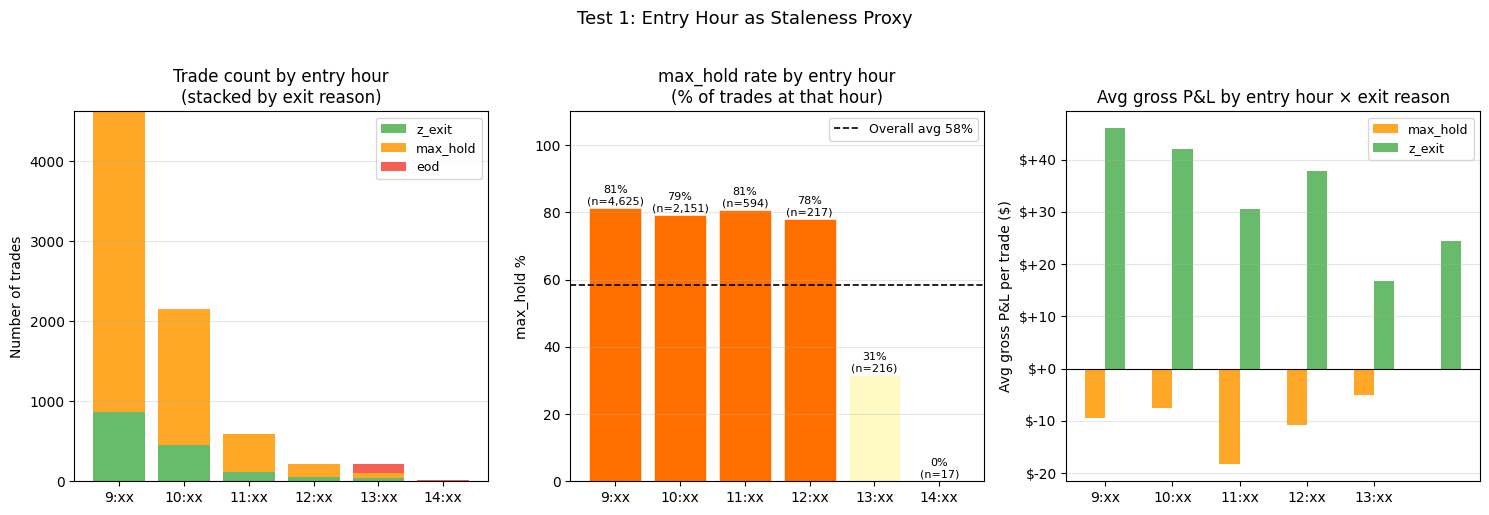

  Hour   Total   max_hold%   z_exit%   mh avg gross   ze avg gross
──────────────────────────────────────────────────────────────────────
     9   4,625       81.1%     18.9%         $-9.47        $+46.01
    10   2,151       79.2%     20.8%         $-7.45        $+42.04
    11     594       80.6%     19.4%        $-18.33        $+30.57
    12     217       77.9%     22.1%        $-10.72        $+37.78
    13     216       31.5%     17.1%         $-5.08        $+16.71
    14      17        0.0%     17.6%              —        $+24.45


In [2]:
trades_h = trades_df.with_columns(
    pl.col('entry_time').dt.hour().alias('entry_hour')
)

# ── Counts and max_hold rate by entry hour ────────────────────────────────
by_hour = (
    trades_h.group_by('entry_hour').agg([
        pl.len().alias('total'),
        (pl.col('exit_reason') == 'max_hold').sum().alias('max_hold_n'),
        (pl.col('exit_reason') == 'z_exit').sum().alias('z_exit_n'),
        (pl.col('exit_reason') == 'eod').sum().alias('eod_n'),
    ])
    .with_columns(
        (pl.col('max_hold_n') / pl.col('total') * 100).alias('max_hold_pct'),
        (pl.col('z_exit_n')  / pl.col('total') * 100).alias('z_exit_pct'),
    )
    .sort('entry_hour')
)

# ── P&L by entry_hour × exit_reason ──────────────────────────────────────
pnl_by_hour = (
    trades_h.group_by(['entry_hour', 'exit_reason']).agg([
        pl.len().alias('n'),
        pl.col('net_pnl').mean().alias('avg_net'),
        pl.col('gross_pnl').mean().alias('avg_gross'),
        (pl.col('net_pnl') > 0).mean().alias('win_rate'),
    ])
    .sort(['entry_hour', 'exit_reason'])
)

# ── Figure: 3 panels ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
hours = by_hour['entry_hour'].to_list()
xlabels = [f"{h}:xx" for h in hours]

# Panel 1: stacked bar — trade counts by exit reason
ax = axes[0]
z_n   = by_hour['z_exit_n'].to_list()
mh_n  = by_hour['max_hold_n'].to_list()
eod_n = by_hour['eod_n'].to_list()
ax.bar(xlabels, z_n,  color='#4CAF50', alpha=0.85, label='z_exit')
ax.bar(xlabels, mh_n,  bottom=z_n, color='#FF9800', alpha=0.85, label='max_hold')
ax.bar(xlabels, eod_n, bottom=[a+b for a,b in zip(z_n, mh_n)],
       color='#F44336', alpha=0.85, label='eod')
ax.set_title('Trade count by entry hour\n(stacked by exit reason)')
ax.set_ylabel('Number of trades')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 2: max_hold rate by entry hour
ax = axes[1]
mh_pct = by_hour['max_hold_pct'].to_list()
bar_colors = ['#FF6F00' if p > 75 else '#FFB300' if p > 60 else '#FFF9C4' for p in mh_pct]
bars = ax.bar(xlabels, mh_pct, color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axhline(np.mean(mh_pct), color='black', linewidth=1.2, linestyle='--',
           label=f'Overall avg {np.mean(mh_pct):.0f}%')
for bar, pct, total in zip(bars, mh_pct, by_hour['total'].to_list()):
    ax.text(bar.get_x() + bar.get_width()/2, pct + 0.5,
            f'{pct:.0f}%\n(n={total:,})', ha='center', va='bottom', fontsize=8)
ax.set_title('max_hold rate by entry hour\n(% of trades at that hour)')
ax.set_ylabel('max_hold %')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 3: avg gross P&L for max_hold trades by entry hour
ax = axes[2]
mh_rows = pnl_by_hour.filter(pl.col('exit_reason') == 'max_hold').sort('entry_hour')
ze_rows = pnl_by_hour.filter(pl.col('exit_reason') == 'z_exit').sort('entry_hour')
w = 0.3
mh_hrs = mh_rows['entry_hour'].to_list()
ze_hrs = ze_rows['entry_hour'].to_list()
ax.bar([h - w/2 for h in mh_hrs], mh_rows['avg_gross'].to_list(),
       width=w, color='#FF9800', alpha=0.85, label='max_hold')
ax.bar([h + w/2 for h in ze_hrs], ze_rows['avg_gross'].to_list(),
       width=w, color='#4CAF50', alpha=0.85, label='z_exit')
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_xticks(mh_hrs)
ax.set_xticklabels([f"{h}:xx" for h in mh_hrs])
ax.set_title('Avg gross P&L by entry hour × exit reason')
ax.set_ylabel('Avg gross P&L per trade ($)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Test 1: Entry Hour as Staleness Proxy', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"{'Hour':>6}  {'Total':>6}  {'max_hold%':>10}  {'z_exit%':>8}  {'mh avg gross':>13}  {'ze avg gross':>13}")
print('─' * 70)
for row in by_hour.iter_rows(named=True):
    h = row['entry_hour']
    mh_g = pnl_by_hour.filter((pl.col('entry_hour')==h)&(pl.col('exit_reason')=='max_hold'))
    ze_g = pnl_by_hour.filter((pl.col('entry_hour')==h)&(pl.col('exit_reason')=='z_exit'))
    mh_gross = f"${float(mh_g['avg_gross'][0]):+.2f}" if len(mh_g) else '  —'
    ze_gross = f"${float(ze_g['avg_gross'][0]):+.2f}" if len(ze_g) else '  —'
    print(f"  {h:>4}  {row['total']:>6,}  {row['max_hold_pct']:>9.1f}%  "
          f"{row['z_exit_pct']:>7.1f}%  {mh_gross:>13}  {ze_gross:>13}")

---
## Test 3: Z-score at open — overnight carry-over classification

For each trade, reconstruct the z-score at the **first 15-min bar of the trading day**
using the same rolling window as the backtest (`zscore_window_days=5`).

- **Stale (overnight carry):** z at bar-0 was already `≥ z_entry` — the spread was
  wide before today even opened. We entered because it *stayed* wide.
- **Fresh (intraday divergence):** z at bar-0 was `< z_entry` — the spread developed
  during today's session before we entered.

Hedge ratio is reconstructed from `shares_b / shares_a` (since `shares_b = hedge_ratio × shares_a`).

**Computation note:** For each unique (ticker_a, ticker_b, trade_date), we load prices
with the rolling lookback window and compute the z-score series. We only need the
value at the first bar of the trade date.

In [3]:
import math
from tqdm.auto import tqdm

# ── Prepare trade-level inputs ────────────────────────────────────────────
trades_work = trades_df.with_columns([
    pl.col('entry_time').dt.date().alias('trade_date'),
    # Reconstruct hedge ratio: shares_b = hedge_ratio * shares_a
    (pl.col('shares_b') / pl.col('shares_a')).alias('hedge_ratio'),
])

# Unique (ticker_a, ticker_b, trade_date) combos to reconstruct
unique_combos = (
    trades_work
    .select(['ticker_a', 'ticker_b', 'trade_date', 'hedge_ratio'])
    .unique(['ticker_a', 'ticker_b', 'trade_date'])
    .sort(['trade_date', 'ticker_a', 'ticker_b'])
)
print(f"Unique (pair, date) combos to reconstruct: {len(unique_combos):,}")

# ── Price cache: load once per ticker over full date range ────────────────
lookback_days   = ZSCORE_WINDOW_DAYS + 5   # extra buffer for weekends/holidays
all_tickers     = set(trades_df['ticker_a'].to_list()) | set(trades_df['ticker_b'].to_list())
all_dates       = trades_work['trade_date'].unique().sort().to_list()
data_start      = all_dates[0] - dt.timedelta(days=lookback_days * 2)
data_end        = all_dates[-1]

print(f"Loading prices for {len(all_tickers)} tickers "
      f"from {data_start} to {data_end} …")

price_cache: dict[str, pl.DataFrame] = {}
for ticker in tqdm(sorted(all_tickers), desc='Loading prices'):
    try:
        df = load_processed(ticker, TIMEFRAME,
                            start_date=str(data_start),
                            end_date=str(data_end))
        if df is not None and len(df) > 0:
            price_cache[ticker] = df.sort('timestamp')
    except FileNotFoundError:
        pass

print(f"Loaded {len(price_cache)} tickers into cache.")

Unique (pair, date) combos to reconstruct: 7,694
Loading prices for 199 tickers from 2022-06-21 to 2024-07-01 …


Loading prices:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded 199 tickers into cache.


In [4]:
def compute_z_at_open(
    ticker_a: str,
    ticker_b: str,
    hedge_ratio: float,
    trade_date: dt.date,
    price_cache: dict,
    zscore_window: int,
) -> float | None:
    """
    Compute the z-score of the log-spread at the first bar of trade_date.
    Uses a rolling mean/std computed over the preceding zscore_window bars.
    Returns None if insufficient data.
    """
    df_a = price_cache.get(ticker_a)
    df_b = price_cache.get(ticker_b)
    if df_a is None or df_b is None:
        return None

    # Align on shared timestamps up to and including trade_date
    ts_a = {r['timestamp']: r['close']
            for r in df_a.filter(pl.col('timestamp').dt.date() <= trade_date)
            .select(['timestamp','close']).iter_rows(named=True)}
    ts_b = {r['timestamp']: r['close']
            for r in df_b.filter(pl.col('timestamp').dt.date() <= trade_date)
            .select(['timestamp','close']).iter_rows(named=True)}

    shared = sorted(set(ts_a) & set(ts_b))
    if len(shared) < zscore_window + 1:
        return None

    # Build log-spread series
    log_spreads = np.array([
        math.log(ts_a[t]) - hedge_ratio * math.log(ts_b[t])
        for t in shared
        if ts_a[t] > 0 and ts_b[t] > 0
    ])

    if len(log_spreads) < zscore_window + 1:
        return None

    # Find the index of the first bar on trade_date
    shared_dates = [t.date() if hasattr(t, 'date') else
                    t.to_pydatetime().date() if hasattr(t, 'to_pydatetime') else
                    dt.date.fromisoformat(str(t)[:10])
                    for t in shared]
    first_bar_idx = next(
        (i for i, d in enumerate(shared_dates) if d == trade_date), None
    )
    if first_bar_idx is None or first_bar_idx < zscore_window:
        return None

    # Rolling z-score at first_bar_idx: use the zscore_window bars ending at
    # first_bar_idx - 1 (i.e., the lookback BEFORE this bar, matching how the
    # signal generator computes it)
    window = log_spreads[first_bar_idx - zscore_window : first_bar_idx]
    mu  = window.mean()
    std = window.std(ddof=1)
    if std < 1e-10:
        return None

    z = (log_spreads[first_bar_idx] - mu) / std
    return float(z)


# ── Compute z at open for every unique (pair, date) ───────────────────────
z_at_open_map: dict[tuple, float | None] = {}

for row in tqdm(unique_combos.iter_rows(named=True), total=len(unique_combos),
                desc='Reconstructing z at open'):
    key = (row['ticker_a'], row['ticker_b'], row['trade_date'])
    z_at_open_map[key] = compute_z_at_open(
        ticker_a     = row['ticker_a'],
        ticker_b     = row['ticker_b'],
        hedge_ratio  = row['hedge_ratio'],
        trade_date   = row['trade_date'],
        price_cache  = price_cache,
        zscore_window= ZSCORE_WINDOW,
    )

found = sum(1 for v in z_at_open_map.values() if v is not None)
print(f"z_at_open computed for {found:,} / {len(z_at_open_map):,} combos")

Reconstructing z at open:   0%|          | 0/7694 [00:00<?, ?it/s]

z_at_open computed for 7,694 / 7,694 combos


In [5]:
# ── Join z_at_open back to trades ─────────────────────────────────────────
z_vals = [
    z_at_open_map.get((row['ticker_a'], row['ticker_b'], row['trade_date']))
    for row in trades_work.iter_rows(named=True)
]

trades_z = trades_work.with_columns(
    pl.Series('z_at_open', z_vals, dtype=pl.Float64)
).with_columns(
    pl.col('z_at_open').abs().alias('abs_z_at_open')
).with_columns(
    pl.when(pl.col('abs_z_at_open') >= Z_ENTRY)
      .then(pl.lit('stale (carry-over)'))
      .when(pl.col('z_at_open').is_null())
      .then(pl.lit('unknown'))
      .otherwise(pl.lit('fresh (intraday)'))
      .alias('entry_type')
)

print("Entry type distribution:")
print(trades_z.group_by('entry_type').len().sort('entry_type'))
print()

# ── Max_hold rate: fresh vs stale ─────────────────────────────────────────
summary = (
    trades_z.filter(pl.col('entry_type') != 'unknown')
    .group_by(['entry_type', 'exit_reason']).agg([
        pl.len().alias('n'),
        pl.col('net_pnl').mean().alias('avg_net'),
        pl.col('gross_pnl').mean().alias('avg_gross'),
        (pl.col('net_pnl') > 0).mean().alias('win_rate'),
        pl.col('net_pnl').sum().alias('total_net'),
    ])
    .sort(['entry_type', 'exit_reason'])
)

by_type = (
    trades_z.filter(pl.col('entry_type') != 'unknown')
    .group_by('entry_type').agg([
        pl.len().alias('total'),
        (pl.col('exit_reason') == 'max_hold').sum().alias('max_hold_n'),
        (pl.col('exit_reason') == 'z_exit').sum().alias('z_exit_n'),
    ])
    .with_columns(
        (pl.col('max_hold_n') / pl.col('total') * 100).alias('max_hold_pct'),
        (pl.col('z_exit_n')  / pl.col('total') * 100).alias('z_exit_pct'),
    )
    .sort('entry_type')
)
print("max_hold rate: fresh vs stale")
print(by_type)

Entry type distribution:
shape: (2, 2)
┌────────────────────┬──────┐
│ entry_type         ┆ len  │
│ ---                ┆ ---  │
│ str                ┆ u32  │
╞════════════════════╪══════╡
│ fresh (intraday)   ┆ 2734 │
│ stale (carry-over) ┆ 5086 │
└────────────────────┴──────┘

max_hold rate: fresh vs stale
shape: (2, 6)
┌────────────────────┬───────┬────────────┬──────────┬──────────────┬────────────┐
│ entry_type         ┆ total ┆ max_hold_n ┆ z_exit_n ┆ max_hold_pct ┆ z_exit_pct │
│ ---                ┆ ---   ┆ ---        ┆ ---      ┆ ---          ┆ ---        │
│ str                ┆ u32   ┆ u32        ┆ u32      ┆ f64          ┆ f64        │
╞════════════════════╪═══════╪════════════╪══════════╪══════════════╪════════════╡
│ fresh (intraday)   ┆ 2734  ┆ 2053       ┆ 572      ┆ 75.091441    ┆ 20.921726  │
│ stale (carry-over) ┆ 5086  ┆ 4119       ┆ 951      ┆ 80.987023    ┆ 18.698388  │
└────────────────────┴───────┴────────────┴──────────┴──────────────┴────────────┘


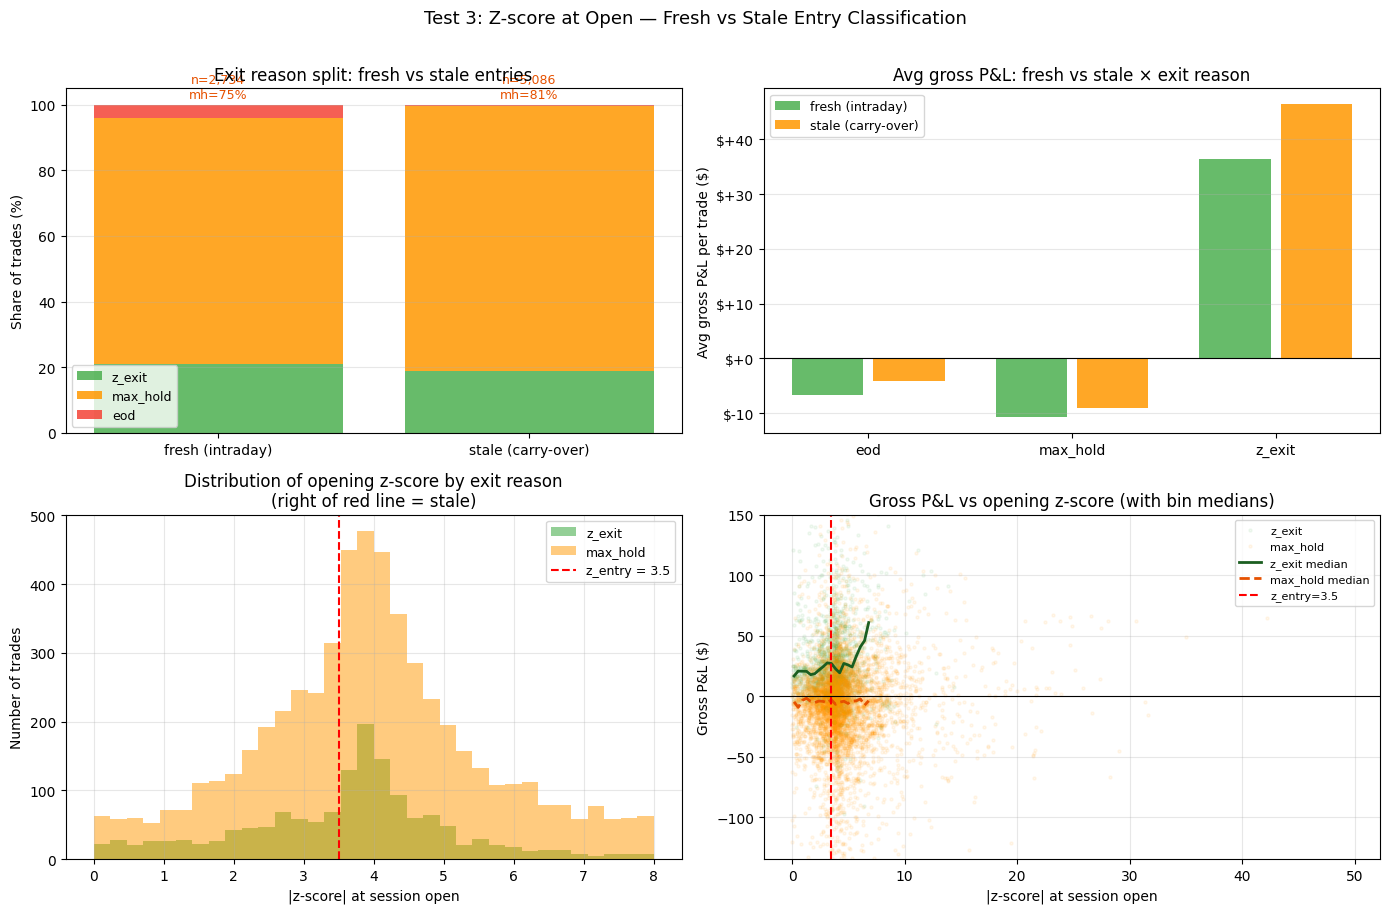

════════════════════════════════════════════════════════════
KEY RESULTS: FRESH vs STALE
════════════════════════════════════════════════════════════

  FRESH (INTRADAY)  (n=2,734)
    max_hold rate : 75.1%
    z_exit rate   : 20.9%
    max_hold avg net P&L : $-17.03  win rate: 31.3%
    z_exit  avg net P&L  : $+29.80  win rate: 87.2%

  STALE (CARRY-OVER)  (n=5,086)
    max_hold rate : 81.0%
    z_exit rate   : 18.7%
    max_hold avg net P&L : $-15.03  win rate: 36.6%
    z_exit  avg net P&L  : $+40.22  win rate: 86.4%


In [6]:
known = trades_z.filter(pl.col('entry_type') != 'unknown')
fresh  = known.filter(pl.col('entry_type') == 'fresh (intraday)')
stale  = known.filter(pl.col('entry_type') == 'stale (carry-over)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Panel 1: max_hold rate — fresh vs stale ───────────────────────────────
ax = axes[0, 0]
labels = by_type['entry_type'].to_list()
mh_pcts = by_type['max_hold_pct'].to_list()
ze_pcts = by_type['z_exit_pct'].to_list()
eod_pcts = [100 - m - z for m, z in zip(mh_pcts, ze_pcts)]
x = range(len(labels))
ax.bar(x, ze_pcts,  color='#4CAF50', alpha=0.85, label='z_exit')
ax.bar(x, mh_pcts,  bottom=ze_pcts, color='#FF9800', alpha=0.85, label='max_hold')
ax.bar(x, eod_pcts, bottom=[a+b for a,b in zip(ze_pcts,mh_pcts)],
       color='#F44336', alpha=0.85, label='eod')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Share of trades (%)')
ax.set_title('Exit reason split: fresh vs stale entries')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for xi, (mh, total) in enumerate(zip(by_type['max_hold_n'].to_list(),
                                      by_type['total'].to_list())):
    ax.text(xi, 102, f'n={total:,}\nmh={mh/total:.0%}',
            ha='center', fontsize=9, color='#E65100')

# ── Panel 2: Avg gross P&L per trade — fresh vs stale × exit reason ───────
ax = axes[0, 1]
for et, color, offset in [('fresh (intraday)', '#4CAF50', -0.2),
                            ('stale (carry-over)', '#FF9800', 0.2)]:
    sub = summary.filter(pl.col('entry_type') == et).sort('exit_reason')
    reasons = sub['exit_reason'].to_list()
    pos = [['eod','max_hold','z_exit'].index(r) + offset for r in reasons]
    ax.bar(pos, sub['avg_gross'].to_list(), width=0.35,
           color=color, alpha=0.85, label=et)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['eod', 'max_hold', 'z_exit'])
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_ylabel('Avg gross P&L per trade ($)')
ax.set_title('Avg gross P&L: fresh vs stale × exit reason')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Panel 3: Distribution of |z_at_open| coloured by exit reason ──────────
ax = axes[1, 0]
bins = np.linspace(0, 8, 35)
for reason, color, alpha in [('z_exit','#4CAF50',0.6), ('max_hold','#FF9800',0.5)]:
    sub = known.filter(pl.col('exit_reason') == reason)['abs_z_at_open'].drop_nulls().to_numpy()
    ax.hist(sub, bins=bins, color=color, alpha=alpha, label=reason)
ax.axvline(Z_ENTRY, color='red', linewidth=1.5, linestyle='--',
           label=f'z_entry = {Z_ENTRY}')
ax.set_xlabel('|z-score| at session open')
ax.set_ylabel('Number of trades')
ax.set_title('Distribution of opening z-score by exit reason\n(right of red line = stale)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Panel 4: |z_at_open| vs gross P&L — scatter with medians ─────────────
ax = axes[1, 1]
for reason, color in [('z_exit','#4CAF50'), ('max_hold','#FF9800')]:
    sub = known.filter(pl.col('exit_reason') == reason)
    z_arr = sub['abs_z_at_open'].to_numpy()
    g_arr = sub['gross_pnl'].to_numpy()
    ax.scatter(z_arr, g_arr, alpha=0.07, s=5, color=color, label=reason, rasterized=True)

# Rolling median of gross P&L over binned z_at_open
bin_edges = np.linspace(0, 7, 20)
bin_mids  = (bin_edges[:-1] + bin_edges[1:]) / 2
for reason, color, ls in [('z_exit','#1B5E20','-'), ('max_hold','#E65100','--')]:
    sub = known.filter(pl.col('exit_reason') == reason)
    z_arr = sub['abs_z_at_open'].to_numpy()
    g_arr = sub['gross_pnl'].to_numpy()
    meds = []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (z_arr >= lo) & (z_arr < hi)
        meds.append(np.median(g_arr[mask]) if mask.sum() > 5 else np.nan)
    ax.plot(bin_mids, meds, color=color, linewidth=2, linestyle=ls,
            label=f'{reason} median')

ax.axvline(Z_ENTRY, color='red', linewidth=1.5, linestyle='--', label=f'z_entry={Z_ENTRY}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('|z-score| at session open')
ax.set_ylabel('Gross P&L ($)')
ax.set_ylim(np.percentile(known['gross_pnl'].to_numpy(), 2),
            np.percentile(known['gross_pnl'].to_numpy(), 98))
ax.set_title('Gross P&L vs opening z-score (with bin medians)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Test 3: Z-score at Open — Fresh vs Stale Entry Classification',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Key numbers ───────────────────────────────────────────────────────────
print('═' * 60)
print('KEY RESULTS: FRESH vs STALE')
print('═' * 60)
for row in by_type.iter_rows(named=True):
    et = row['entry_type']
    sub_s = summary.filter(pl.col('entry_type') == et)
    mh = sub_s.filter(pl.col('exit_reason') == 'max_hold')
    ze = sub_s.filter(pl.col('exit_reason') == 'z_exit')
    mh_net = float(mh['avg_net'][0]) if len(mh) else float('nan')
    ze_net = float(ze['avg_net'][0]) if len(ze) else float('nan')
    mh_wr  = float(mh['win_rate'][0]) if len(mh) else float('nan')
    ze_wr  = float(ze['win_rate'][0]) if len(ze) else float('nan')
    print(f"\n  {et.upper()}  (n={row['total']:,})")
    print(f"    max_hold rate : {row['max_hold_pct']:.1f}%")
    print(f"    z_exit rate   : {row['z_exit_pct']:.1f}%")
    print(f"    max_hold avg net P&L : ${mh_net:+.2f}  win rate: {mh_wr:.1%}")
    print(f"    z_exit  avg net P&L  : ${ze_net:+.2f}  win rate: {ze_wr:.1%}")

---
## Interpretation

### If the hypothesis is confirmed (stale >> fresh max_hold rate)
- Stale (carry-over) entries have materially higher max_hold rates than fresh (intraday) entries
- The fix is a **freshness filter** in the signal generator: block entry if `|z| >= z_entry` at the first bar of the session (meaning the position would be a carry-over, not a new divergence)
- Expected mechanism: overnight carry-overs reflect structural gaps that are maintained by bid-ask dynamics at the open, not mean-revertible intraday spreads

### If the hypothesis is NOT confirmed (fresh ≈ stale max_hold rate)
- The problem is not staleness — it's something else:
  - The z_entry threshold is too low (noisy entries regardless of when they happen)
  - The pairs selected don't actually revert within the holding window
  - The max_holding_minutes is too short for the pairs' natural reversion speed
- In that case: **Option 1** (raise z_entry) or **Option 2** (add z_stop) are the better levers